In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import geopandas as gpd

In [2]:
# url = "https://www2.census.gov/geo/tiger/GENZ2022/shp/cb_2022_us_state_5m.zip"
# gdf = gpd.read_file(url)
# gdf.to_file("us_states.geojson", driver="GeoJSON")

In [3]:
non_lower_48_names = [
    "District of Columbia",
    "Guam",
    "Commonwealth of the Northern Mariana Islands",
    "American Samoa",
    "United States Virgin Islands",
    "Hawaii",
    "Puerto Rico",
    "Alaska",
]

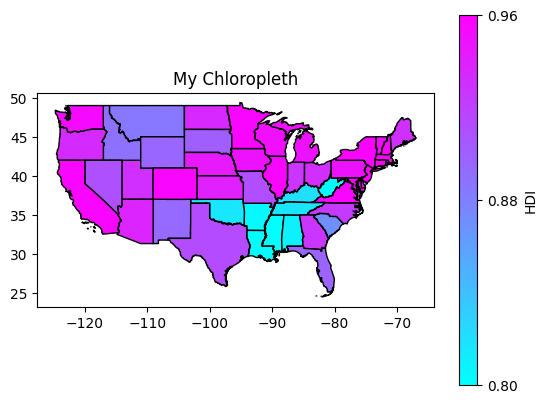

In [4]:
gdf = gpd.read_file("us_states.geojson")
lower_48_mask = ~gdf["NAME"].isin(non_lower_48_names)
lower_48 = gdf[lower_48_mask]
assert len(lower_48) == 48

hdi = pd.read_csv("hdi.csv", index_col="state")

lower_48 = lower_48.merge(hdi, how="left", left_on="NAME", right_index=True)
assert not lower_48["hdi"].hasnans

lower_48 = lower_48.sort_values("hdi")
lower_48["hdi_rank"] = np.arange(48)

min_hdi = lower_48["hdi"].min()
max_hdi = lower_48["hdi"].max()
lower_48["hdi"] = (lower_48["hdi"] - min_hdi) / (max_hdi - min_hdi)

df = pd.read_csv("state_vote_and_income.csv")
df = df[df["st_year"] == 2000][["st_state", "st_income"]].set_index("st_state")
lower_48 = lower_48.merge(right=df, how="left", left_on="NAME", right_on="st_state")

lower_48 = lower_48.sort_values("st_income")
lower_48["st_income_rank"] = np.arange(48)

cmap = cmap = mpl.colormaps["cool"]
facecolor = lower_48["hdi"].apply(cmap)
lower_48.plot(edgecolor="black", facecolor=facecolor)

sm = plt.cm.ScalarMappable(cmap=cmap)

cb = plt.colorbar(sm, ax=plt.gca(), label="HDI")
cb.set_ticks([0, 0.5, 1])
cb.set_ticklabels(
    [f"{min_hdi:.2f}", f"{0.5*(min_hdi + max_hdi):.2f}", f"{max_hdi:.2f}"]
)

plt.title("My Chloropleth")
plt.show()

<Axes: xlabel='st_income_rank', ylabel='hdi_rank'>

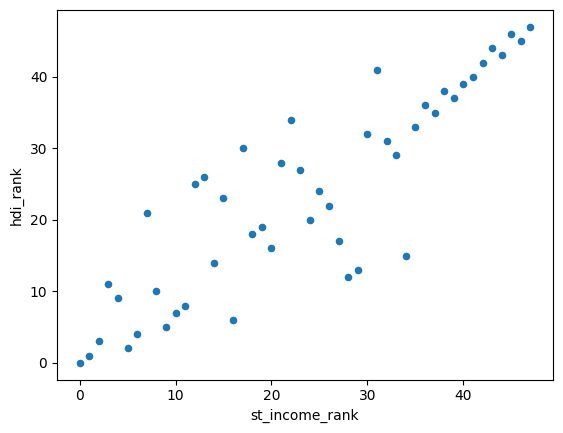

In [5]:
lower_48.plot.scatter(x="st_income_rank", y="hdi_rank")

<Axes: xlabel='st_income', ylabel='hdi'>

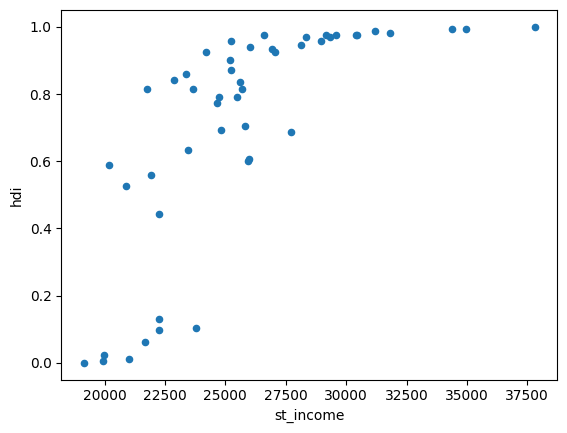

In [6]:
lower_48.plot.scatter(x="st_income", y="hdi")